# Grid ablation optimization benchmark

Compare `run_grid_ablation.py` (full pipeline per cell) vs `daniel_run_grid_ablation.py` (factorized) on the 10 `source.png` images from `grid_metrics_sdturbo_random10_20260626_104807`.

Sweep: 11×11 `t_start` × `t_end` grid, `t_delta=0.0` only.

In [ ]:
import io
import json
import os
import subprocess
import sys
import time
from datetime import datetime
from pathlib import Path

import numpy as np
from PIL import Image

REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == "scripts":
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

CHORDEDIT_PYTHON = Path("/data/home/mirick/miniconda3/envs/chordedit/bin/python")
PYTHON = Path(os.environ.get("BENCHMARK_PYTHON", CHORDEDIT_PYTHON if CHORDEDIT_PYTHON.exists() else sys.executable))

GPU_ID = os.environ.get("BENCHMARK_GPU", "2")
MODEL_ROOT = "/shared/ssd_30T/mirick/models/sd-turbo"
GRID_ROOT = Path("/shared/ssd_30T/mirick/grid_metrics_sdturbo_random10_20260626_104807")
PIE_MAPPING = Path("/shared/ssd_30T/mirick/datasets/PIE-Bench_v1/mapping_file.json")

BENCH_ROOT = REPO_ROOT / "outputs" / "benchmark_random10"
DATA_ROOT = BENCH_ROOT / "data"
RUN_TS = datetime.now().strftime("%Y%m%d_%H%M%S")
REF_OUT = BENCH_ROOT / f"run_grid_ablation_{RUN_TS}"
DAN_OUT = BENCH_ROOT / f"daniel_run_grid_ablation_{RUN_TS}"
JPEG_QUALITY = 75  # matches daniel_run_grid_ablation.py

print(f"repo: {REPO_ROOT}")
print(f"python: {PYTHON}")
print(f"GPU: {GPU_ID}")

repo: /data/home/mirick/ChordEdit/daniel-grid-optimizations
python: /data/home/mirick/miniconda3/envs/chordedit/bin/python
GPU: 2


In [2]:
def prepare_benchmark_data() -> int:
    mapping = json.loads(PIE_MAPPING.read_text(encoding="utf-8"))
    sources = sorted(GRID_ROOT.glob("*/source.png"))
    if not sources:
        raise FileNotFoundError(f"No source.png under {GRID_ROOT}")

    DATA_ROOT.mkdir(parents=True, exist_ok=True)
    for src in sources:
        sample_dir = DATA_ROOT / src.parent.name
        sample_dir.mkdir(exist_ok=True)
        img_link = sample_dir / "i.jpg"
        if img_link.exists() or img_link.is_symlink():
            img_link.unlink()
        img_link.symlink_to(src.resolve())
        sample_id = src.parent.name.split("_")[-1]
        meta = mapping[sample_id]
        record = {
            "edit_id": "e1",
            "original_prompt": meta["original_prompt"],
            "edited_prompt": meta["editing_prompt"],
            "edit_prompt": meta["editing_instruction"],
            "task_type": "object",
        }
        (sample_dir / "meta.jsonl").write_text(json.dumps(record) + "\n", encoding="utf-8")
    return len(sources)

n_samples = prepare_benchmark_data()
print(f"Prepared {n_samples} samples under {DATA_ROOT}")

Prepared 10 samples under /data/home/mirick/ChordEdit/daniel-grid-optimizations/outputs/benchmark_random10/data


In [3]:
def run_ablation(script_name: str, output_root: Path) -> float:
    cmd = [
        str(PYTHON),
        str(REPO_ROOT / "scripts" / script_name),
        "--model-root", MODEL_ROOT,
        "--model-type", "sd",
        "--data-root", str(DATA_ROOT),
        "--output-root", str(output_root),
        "--max-records", str(int(os.environ.get("BENCHMARK_MAX_RECORDS", n_samples))),
        "--overwrite",
        "--device", "cuda:0",
    ]
    env = os.environ.copy()
    env["CUDA_VISIBLE_DEVICES"] = GPU_ID
    print(" ".join(cmd))
    t0 = time.perf_counter()
    proc = subprocess.run(cmd, cwd=REPO_ROOT, env=env, check=True)
    elapsed = time.perf_counter() - t0
    print(f"{script_name} finished in {elapsed:.1f}s (exit {proc.returncode})")
    return elapsed

In [4]:
ref_seconds = run_ablation("run_grid_ablation.py", REF_OUT)

/data/home/mirick/miniconda3/envs/chordedit/bin/python /data/home/mirick/ChordEdit/daniel-grid-optimizations/scripts/run_grid_ablation.py --model-root /shared/ssd_30T/mirick/models/sd-turbo --model-type sd --data-root /data/home/mirick/ChordEdit/daniel-grid-optimizations/outputs/benchmark_random10/data --output-root /data/home/mirick/ChordEdit/daniel-grid-optimizations/outputs/benchmark_random10/run_grid_ablation --max-records 10 --overwrite --device cuda:0


2026-07-02 09:07:54,555 | INFO | grid_ablation | Loaded 10 record(s) from /data/home/mirick/ChordEdit/daniel-grid-optimizations/outputs/benchmark_random10/data
2026-07-02 09:07:54,555 | INFO | grid_ablation | Base edit config copied from app.py: {'noise_samples': 1, 'n_steps': 1, 't_start': 0.9, 't_end': 0.3, 't_delta': 0.0, 'step_scale': 1.0, 'cleanup': True}
2026-07-02 09:07:54,555 | INFO | grid_ablation | Grid values: [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
2026-07-02 09:07:54,555 | INFO | grid_ablation | t_delta conditions: [0.0]
2026-07-02 09:07:54,555 | INFO | grid_ablation | Output root: /data/home/mirick/ChordEdit/daniel-grid-optimizations/outputs/benchmark_random10/run_grid_ablation
Loading weights: 100%|██████████| 372/372 [00:00<00:00, 8268.27it/s]
2026-07-02 09:07:58,223 | INFO | grid_ablation | Processing 1/10: 0_random_140_000000000000_e1


t_start:        0.0 t_end:        0.0 t_delta:        0.0 n_steps:          1
t_start:        0.1 t_end:        0.0 t_delta:        0.0 n_steps:          1
t_start:        0.2 t_end:        0.0 t_delta:        0.0 n_steps:          1
t_start:        0.3 t_end:        0.0 t_delta:        0.0 n_steps:          1
t_start:        0.4 t_end:        0.0 t_delta:        0.0 n_steps:          1
t_start:        0.5 t_end:        0.0 t_delta:        0.0 n_steps:          1
t_start:        0.6 t_end:        0.0 t_delta:        0.0 n_steps:          1
t_start:        0.7 t_end:        0.0 t_delta:        0.0 n_steps:          1
t_start:        0.8 t_end:        0.0 t_delta:        0.0 n_steps:          1
t_start:        0.9 t_end:        0.0 t_delta:        0.0 n_steps:          1
t_start:        1.0 t_end:        0.0 t_delta:        0.0 n_steps:          1
t_start:        0.0 t_end:        0.1 t_delta:        0.0 n_steps:          1
t_start:        0.1 t_end:        0.1 t_delta:        0.0 n_step

2026-07-02 09:10:20,983 | INFO | grid_ablation | Processing 2/10: 0_random_140_000000000001_e1


t_start:        0.0 t_end:        0.0 t_delta:        0.0 n_steps:          1
t_start:        0.1 t_end:        0.0 t_delta:        0.0 n_steps:          1
t_start:        0.2 t_end:        0.0 t_delta:        0.0 n_steps:          1
t_start:        0.3 t_end:        0.0 t_delta:        0.0 n_steps:          1
t_start:        0.4 t_end:        0.0 t_delta:        0.0 n_steps:          1
t_start:        0.5 t_end:        0.0 t_delta:        0.0 n_steps:          1
t_start:        0.6 t_end:        0.0 t_delta:        0.0 n_steps:          1
t_start:        0.7 t_end:        0.0 t_delta:        0.0 n_steps:          1
t_start:        0.8 t_end:        0.0 t_delta:        0.0 n_steps:          1
t_start:        0.9 t_end:        0.0 t_delta:        0.0 n_steps:          1
t_start:        1.0 t_end:        0.0 t_delta:        0.0 n_steps:          1
t_start:        0.0 t_end:        0.1 t_delta:        0.0 n_steps:          1
t_start:        0.1 t_end:        0.1 t_delta:        0.0 n_step

...

t_start:        0.0 t_end:        0.0 t_delta:        0.0 n_steps:          1
t_start:        0.1 t_end:        0.0 t_delta:        0.0 n_steps:          1
t_start:        0.2 t_end:        0.0 t_delta:        0.0 n_steps:          1
t_start:        0.3 t_end:        0.0 t_delta:        0.0 n_steps:          1
t_start:        0.4 t_end:        0.0 t_delta:        0.0 n_steps:          1
t_start:        0.5 t_end:        0.0 t_delta:        0.0 n_steps:          1
t_start:        0.6 t_end:        0.0 t_delta:        0.0 n_steps:          1
t_start:        0.7 t_end:        0.0 t_delta:        0.0 n_steps:          1
t_start:        0.8 t_end:        0.0 t_delta:        0.0 n_steps:          1
t_start:        0.9 t_end:        0.0 t_delta:        0.0 n_steps:          1
t_start:        1.0 t_end:        0.0 t_delta:        0.0 n_steps:          1
t_start:        0.0 t_end:        0.1 t_delta:        0.0 n_steps:          1
t_start:        0.1 t_end:        0.1 t_delta:        0.0 n_step

2026-07-02 09:29:02,514 | INFO | grid_ablation | Processing 10/10: 0_random_140_000000000009_e1


t_start:        0.0 t_end:        0.0 t_delta:        0.0 n_steps:          1
t_start:        0.1 t_end:        0.0 t_delta:        0.0 n_steps:          1
t_start:        0.2 t_end:        0.0 t_delta:        0.0 n_steps:          1
t_start:        0.3 t_end:        0.0 t_delta:        0.0 n_steps:          1
t_start:        0.4 t_end:        0.0 t_delta:        0.0 n_steps:          1
t_start:        0.5 t_end:        0.0 t_delta:        0.0 n_steps:          1
t_start:        0.6 t_end:        0.0 t_delta:        0.0 n_steps:          1
t_start:        0.7 t_end:        0.0 t_delta:        0.0 n_steps:          1
t_start:        0.8 t_end:        0.0 t_delta:        0.0 n_steps:          1
t_start:        0.9 t_end:        0.0 t_delta:        0.0 n_steps:          1
t_start:        1.0 t_end:        0.0 t_delta:        0.0 n_steps:          1
t_start:        0.0 t_end:        0.1 t_delta:        0.0 n_steps:          1
t_start:        0.1 t_end:        0.1 t_delta:        0.0 n_step

2026-07-02 09:31:17,639 | INFO | grid_ablation | Finished grid ablations. Results saved in /data/home/mirick/ChordEdit/daniel-grid-optimizations/outputs/benchmark_random10/run_grid_ablation


run_grid_ablation.py finished in 1412.3s (exit 0)


In [6]:
dan_seconds = run_ablation("daniel_run_grid_ablation.py", DAN_OUT)

/data/home/mirick/miniconda3/envs/chordedit/bin/python /data/home/mirick/ChordEdit/daniel-grid-optimizations/scripts/daniel_run_grid_ablation.py --model-root /shared/ssd_30T/mirick/models/sd-turbo --model-type sd --data-root /data/home/mirick/ChordEdit/daniel-grid-optimizations/outputs/benchmark_random10/data --output-root /data/home/mirick/ChordEdit/daniel-grid-optimizations/outputs/benchmark_random10/daniel_grid_ablation --max-records 10 --overwrite --device cuda:0


2026-07-02 09:31:56,594 | INFO | daniel_grid_ablation | Loaded 10 record(s) from /data/home/mirick/ChordEdit/daniel-grid-optimizations/outputs/benchmark_random10/data
2026-07-02 09:31:56,594 | INFO | daniel_grid_ablation | Base edit config: {'noise_samples': 1, 'n_steps': 1, 't_start': 0.9, 't_end': 0.3, 't_delta': 0.0, 'step_scale': 1.0, 'cleanup': True}
2026-07-02 09:31:56,595 | INFO | daniel_grid_ablation | Grid values: [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0] (11x11 = 121 cells/image/t_delta)
2026-07-02 09:31:56,595 | INFO | daniel_grid_ablation | t_delta conditions: [0.0]
2026-07-02 09:31:56,595 | INFO | daniel_grid_ablation | Chord edit mode: default
2026-07-02 09:31:56,595 | INFO | daniel_grid_ablation | Per image/t_delta: 1 encode, 1 prompt encode, 1 noise setup, 11 transports, 121 cleanups, 121 decodes (run_grid_ablation.py would run 121 full pipelines)
2026-07-02 09:31:56,595 | INFO | daniel_grid_ablation | Output root: /data/home/mirick/ChordEdit/daniel-grid-o

Using optimized _u_estimate (t_delta=0 fast path) ...
Using optimized _u_estimate (t_delta=0 fast path) ...
Using optimized _u_estimate (t_delta=0 fast path) ...
Using optimized _u_estimate (t_delta=0 fast path) ...
Using optimized _u_estimate (t_delta=0 fast path) ...
Using optimized _u_estimate (t_delta=0 fast path) ...
Using optimized _u_estimate (t_delta=0 fast path) ...
Using optimized _u_estimate (t_delta=0 fast path) ...
Using optimized _u_estimate (t_delta=0 fast path) ...
Using optimized _u_estimate (t_delta=0 fast path) ...
Using optimized _u_estimate (t_delta=0 fast path) ...


2026-07-02 09:32:45,216 | INFO | daniel_grid_ablation | Processing 2/10: 0_random_140_000000000001_e1


Using optimized _u_estimate (t_delta=0 fast path) ...
Using optimized _u_estimate (t_delta=0 fast path) ...
Using optimized _u_estimate (t_delta=0 fast path) ...
Using optimized _u_estimate (t_delta=0 fast path) ...
Using optimized _u_estimate (t_delta=0 fast path) ...
Using optimized _u_estimate (t_delta=0 fast path) ...
Using optimized _u_estimate (t_delta=0 fast path) ...
Using optimized _u_estimate (t_delta=0 fast path) ...
Using optimized _u_estimate (t_delta=0 fast path) ...
Using optimized _u_estimate (t_delta=0 fast path) ...
Using optimized _u_estimate (t_delta=0 fast path) ...


...

Using optimized _u_estimate (t_delta=0 fast path) ...
Using optimized _u_estimate (t_delta=0 fast path) ...
Using optimized _u_estimate (t_delta=0 fast path) ...
Using optimized _u_estimate (t_delta=0 fast path) ...
Using optimized _u_estimate (t_delta=0 fast path) ...
Using optimized _u_estimate (t_delta=0 fast path) ...
Using optimized _u_estimate (t_delta=0 fast path) ...
Using optimized _u_estimate (t_delta=0 fast path) ...
Using optimized _u_estimate (t_delta=0 fast path) ...
Using optimized _u_estimate (t_delta=0 fast path) ...
Using optimized _u_estimate (t_delta=0 fast path) ...


2026-07-02 09:38:30,464 | INFO | daniel_grid_ablation | Processing 10/10: 0_random_140_000000000009_e1


Using optimized _u_estimate (t_delta=0 fast path) ...
Using optimized _u_estimate (t_delta=0 fast path) ...
Using optimized _u_estimate (t_delta=0 fast path) ...
Using optimized _u_estimate (t_delta=0 fast path) ...
Using optimized _u_estimate (t_delta=0 fast path) ...
Using optimized _u_estimate (t_delta=0 fast path) ...
Using optimized _u_estimate (t_delta=0 fast path) ...
Using optimized _u_estimate (t_delta=0 fast path) ...
Using optimized _u_estimate (t_delta=0 fast path) ...
Using optimized _u_estimate (t_delta=0 fast path) ...
Using optimized _u_estimate (t_delta=0 fast path) ...


2026-07-02 09:39:14,546 | INFO | daniel_grid_ablation | Finished grid ablations. Results saved in /data/home/mirick/ChordEdit/daniel-grid-optimizations/outputs/benchmark_random10/daniel_grid_ablation_20260702_093156


daniel_run_grid_ablation.py finished in 448.5s (exit 0)


In [7]:
def png_as_jpeg_array(png_path: Path) -> np.ndarray:
    img = Image.open(png_path).convert("RGB")
    buf = io.BytesIO()
    img.save(buf, format="JPEG", quality=JPEG_QUALITY)
    buf.seek(0)
    return np.asarray(Image.open(buf).convert("RGB"))


def compare_outputs(ref_root: Path, dan_root: Path) -> dict:
    ref_cells = {p.stem: p for p in ref_root.rglob("t_delta_0/cells/*.png")}
    dan_cells = {p.stem: p for p in dan_root.rglob("t_delta_0/cells/*.jpg")}
    common = sorted(set(ref_cells) & set(dan_cells))
    only_ref = sorted(set(ref_cells) - set(dan_cells))
    only_dan = sorted(set(dan_cells) - set(ref_cells))

    exact = jpeg_match = mismatches = 0
    worst = (0.0, None)
    for stem in common:
        ref_arr = np.asarray(Image.open(ref_cells[stem]).convert("RGB"))
        dan_arr = np.asarray(Image.open(dan_cells[stem]).convert("RGB"))
        ref_jpg = png_as_jpeg_array(ref_cells[stem])
        if np.array_equal(ref_arr, dan_arr):
            exact += 1
        elif np.array_equal(ref_jpg, dan_arr):
            jpeg_match += 1
        else:
            mismatches += 1
            diff = np.abs(ref_jpg.astype(np.int16) - dan_arr.astype(np.int16))
            m = float(diff.max())
            if m > worst[0]:
                worst = (m, stem)

    return {
        "ref_cells": len(ref_cells),
        "dan_cells": len(dan_cells),
        "common": len(common),
        "only_ref": len(only_ref),
        "only_dan": len(only_dan),
        "exact_png_jpg": exact,
        "match_after_jpeg_normalize": jpeg_match,
        "algorithm_mismatches": mismatches,
        "worst_residual": worst,
    }


comparison = compare_outputs(REF_OUT, DAN_OUT)
comparison

{'ref_cells': 121,
 'dan_cells': 0,
 'common': 0,
 'only_ref': 121,
 'only_dan': 0,
 'exact_png_jpg': 0,
 'match_after_jpeg_normalize': 0,
 'algorithm_mismatches': 0,
 'worst_residual': (0.0, None)}

In [8]:
cells_per_image = 11 * 11
total_cells = cells_per_image * n_samples
speedup = ref_seconds / dan_seconds if dan_seconds else float("inf")

summary = {
    "samples": n_samples,
    "cells_per_image": cells_per_image,
    "total_cells": total_cells,
    "t_delta": 0.0,
    "run_grid_ablation_s": round(ref_seconds, 1),
    "daniel_grid_ablation_s": round(dan_seconds, 1),
    "speedup": round(speedup, 2),
    "sec_per_cell_ref": round(ref_seconds / total_cells, 3),
    "sec_per_cell_daniel": round(dan_seconds / total_cells, 3),
    **comparison,
}
summary

{'samples': 10,
 'cells_per_image': 121,
 'total_cells': 1210,
 't_delta': 0.0,
 'run_grid_ablation_s': 1412.3,
 'daniel_grid_ablation_s': 448.5,
 'speedup': 3.15,
 'sec_per_cell_ref': 1.167,
 'sec_per_cell_daniel': 0.371,
 'ref_cells': 121,
 'dan_cells': 0,
 'common': 0,
 'only_ref': 121,
 'only_dan': 0,
 'exact_png_jpg': 0,
 'match_after_jpeg_normalize': 0,
 'algorithm_mismatches': 0,
 'worst_residual': (0.0, None)}

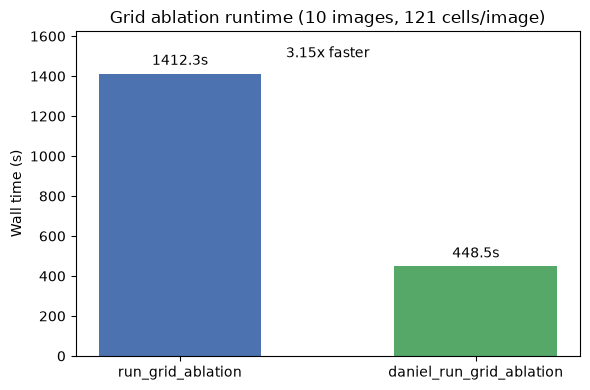

Saved /data/home/mirick/ChordEdit/daniel-grid-optimizations/outputs/benchmark_random10/runtime_comparison.png


In [9]:
import matplotlib.pyplot as plt

labels = ["run_grid_ablation", "daniel_run_grid_ablation"]
times_s = [ref_seconds, dan_seconds]
colors = ["#4C72B0", "#55A868"]

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(labels, times_s, color=colors, width=0.55)
ax.set_ylabel("Wall time (s)")
ax.set_title(f"Grid ablation runtime ({n_samples} images, {cells_per_image} cells/image)")
ax.bar_label(bars, labels=[f"{t:.1f}s" for t in times_s], padding=4)
ax.text(
    0.5, 0.92, f"{speedup:.2f}x faster",
    transform=ax.transAxes, ha="center", fontsize=10,
)
ax.set_ylim(0, max(times_s) * 1.15)
fig.tight_layout()

plot_path = BENCH_ROOT / "runtime_comparison.png"
fig.savefig(plot_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved {plot_path}")

In [12]:
def compare_outputs_per_sample(ref_root: Path, dan_root: Path) -> list[dict]:
    rows = []
    for sample_dir in sorted(p for p in ref_root.iterdir() if p.is_dir()):
        dan_dir = dan_root / sample_dir.name
        cells_dir = sample_dir / "t_delta_0/cells"
        if not cells_dir.is_dir() or not dan_dir.is_dir():
            continue

        exact = jpeg_match = mismatches = 0
        max_residual = 0.0
        for ref_path in sorted(cells_dir.glob("*.png")):
            dan_path = dan_dir / "t_delta_0/cells" / f"{ref_path.stem}.jpg"
            if not dan_path.exists():
                mismatches += 1
                continue
            ref_arr = np.asarray(Image.open(ref_path).convert("RGB"))
            dan_arr = np.asarray(Image.open(dan_path).convert("RGB"))
            ref_jpg = png_as_jpeg_array(ref_path)
            if np.array_equal(ref_arr, dan_arr):
                exact += 1
            elif np.array_equal(ref_jpg, dan_arr):
                jpeg_match += 1
            else:
                mismatches += 1
                diff = np.abs(ref_jpg.astype(np.int16) - dan_arr.astype(np.int16))
                max_residual = max(max_residual, float(diff.max()))

        sample_id = sample_dir.name.split("_")[-2]
        rows.append({
            "sample": sample_dir.name,
            "sample_id": sample_id,
            "cells": exact + jpeg_match + mismatches,
            "exact_png_jpg": exact,
            "match_after_jpeg_normalize": jpeg_match,
            "algorithm_mismatches": mismatches,
            "max_residual": max_residual,
        })
    return rows


per_sample = compare_outputs_per_sample(REF_OUT, DAN_OUT)
per_sample

[]

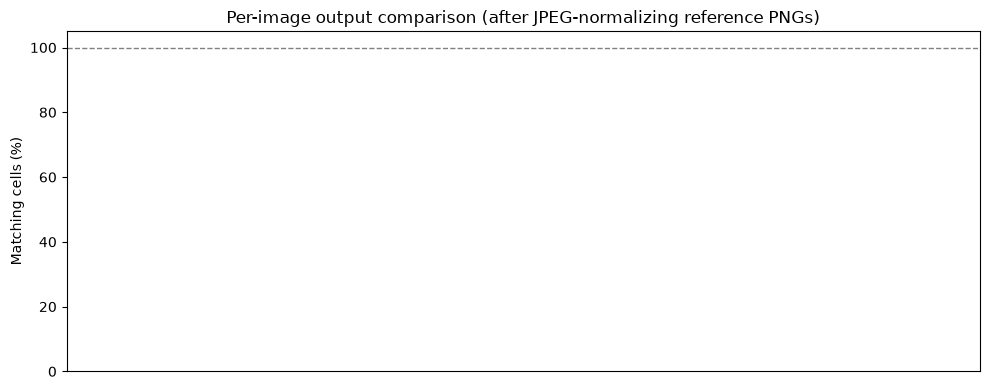

Saved /data/home/mirick/ChordEdit/daniel-grid-optimizations/outputs/benchmark_random10/per_image_differences.png


In [11]:
sample_labels = [row["sample_id"] for row in per_sample]
cell_totals = [row["cells"] for row in per_sample]
match_pct = [
    100.0 * (row["match_after_jpeg_normalize"] + row["exact_png_jpg"]) / row["cells"]
    for row in per_sample
]
mismatch_pct = [100.0 - m for m in match_pct]
bar_colors = ["#C44E52" if m < 100 else "#55A868" for m in match_pct]

fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(len(sample_labels))
ax.bar(x, match_pct, color=bar_colors, width=0.7, label="matching")
if any(m > 0 for m in mismatch_pct):
    ax.bar(x, mismatch_pct, bottom=match_pct, color="#C44E52", width=0.7, label="different")
ax.set_xticks(x, sample_labels, rotation=45, ha="right")
ax.set_ylabel("Matching cells (%)")
ax.set_title("Per-image output comparison (after JPEG-normalizing reference PNGs)")
ax.set_ylim(0, 105)
ax.axhline(100, color="gray", linestyle="--", linewidth=1, zorder=0)
if any(m > 0 for m in mismatch_pct):
    ax.legend(loc="lower right")
fig.tight_layout()

diff_plot_path = BENCH_ROOT / "per_image_differences.png"
fig.savefig(diff_plot_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved {diff_plot_path}")